In [ ]:
from google.colab import files
files.upload()  # Upload kaggle.json here

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"omsubhrasingha","key":"c3ccbdc56b8303b3471927205034ef1f"}'}

In [ ]:
import os
import zipfile

# Create Kaggle folder and move json
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle competitions download -c shl-intern-hiring-assessment

In [ ]:
!unzip -q shl-intern-hiring-assessment.zip

In [ ]:
# STEP 6: List all files in the current directory (to verify contents)
import os
for dirname, _, filenames in os.walk('.'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


./shl-intern-hiring-assessment.zip
./.config/active_config
./.config/.last_opt_in_prompt.yaml
./.config/gce
./.config/.last_update_check.json
./.config/.last_survey_prompt.yaml
./.config/config_sentinel
./.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
./.config/default_configs.db
./.config/logs/2025.04.30/13.36.50.566118.log
./.config/logs/2025.04.30/13.36.58.979052.log
./.config/logs/2025.04.30/13.36.29.848398.log
./.config/logs/2025.04.30/13.37.09.510583.log
./.config/logs/2025.04.30/13.37.00.207659.log
./.config/logs/2025.04.30/13.37.08.828246.log
./.config/configurations/config_default
./Dataset/sample_submission.csv
./Dataset/test.csv
./Dataset/train.csv
./Dataset/audios/train/audio_219.wav
./Dataset/audios/train/audio_687.wav
./Dataset/audios/train/audio_362.wav
./Dataset/audios/train/audio_1035.wav
./Dataset/audios/train/audio_52.wav
./Dataset/audios/train/audio_426.wav
./Dataset/audios/train/audio_950.wav
./Dataset/audios/train/audio_385.wav
./Dataset/au

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from glob import glob

import librosa
import librosa.display
from itertools import cycle

import IPython.display as ipd

sns.set_theme(style="white", palette=None)
color_pal = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_cycle = cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

In [ ]:
training_audio_files = glob("./Dataset/audios/train/*.wav")

In [ ]:
# Check if the list is not empty
if training_audio_files:
    ipd.Audio(training_audio_files[0])
    print(training_audio_files[0])
else:
    print("No audio files found in the specified directory.")

./Dataset/audios/train/audio_219.wav


In [ ]:
y, sr = librosa.load(training_audio_files[0])

print(f"First 10 value of y is {y[:10]}")
print(f"Shape of y is {y.shape}")
print(f"Value of sr is {sr}")

First 10 value of y is [-1.1174102e-04  4.5424684e-05  7.2268900e-05 -4.5712910e-05
  3.8090555e-05  1.0996233e-04  1.7437400e-05  7.3614858e-05
  1.4249637e-04  4.0967872e-05]
Shape of y is (1324647,)
Value of sr is 22050


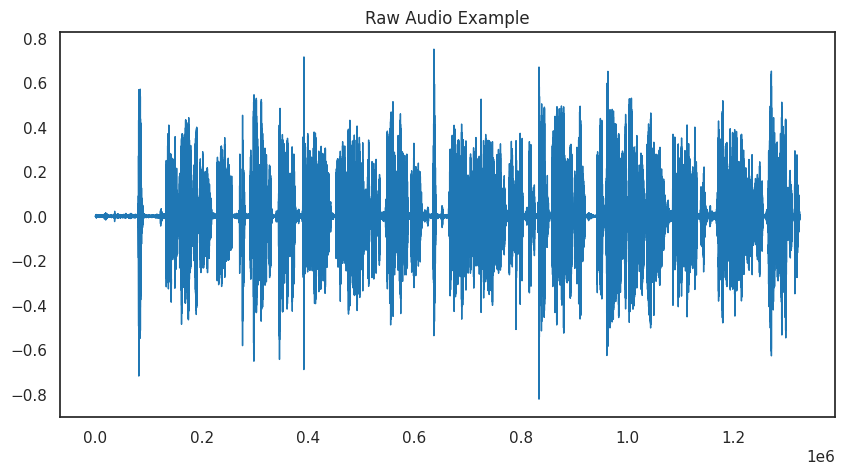

In [ ]:
pd.Series(y).plot(figsize=(10,5), lw=1, title="Raw Audio Example", color=color_pal[0])
plt.show()

In [ ]:
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
S_db.shape

(1025, 2588)

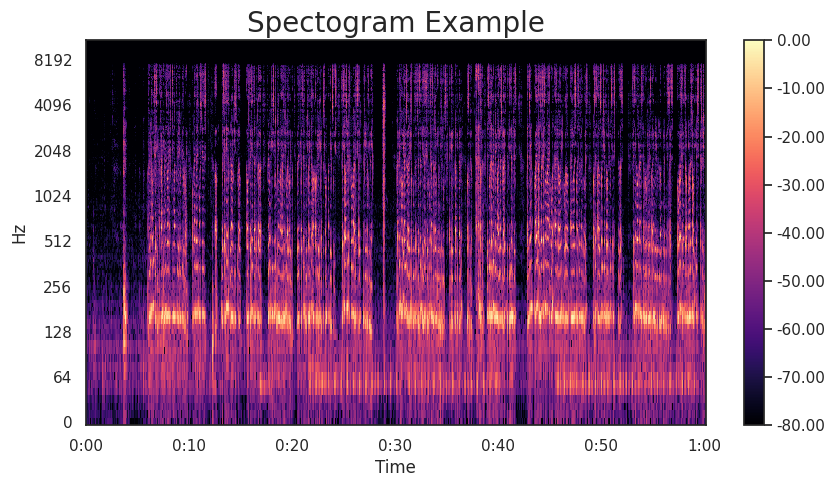

In [ ]:
fig,ax = plt.subplots(figsize=(10,5))
img = librosa.display.specshow(S_db,x_axis='time', y_axis='log', ax = ax)
ax.set_title("Spectogram Example", fontsize=20)
fig.colorbar(img, ax=ax, format=f'%0.2f')
plt.show()

In [ ]:
# Installing dependencies
!pip install -q git+https://github.com/openai/whisper.git
!apt-get -qq install -y ffmpeg
!pip install -q faster-whisper
!pip install -q ctranslate2 --upgrade --extra-index-url https://download.pytorch.org/whl/cu118

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 88.6 MB/s eta

In [ ]:
import whisper
model = whisper.load_model("base")
audio_path = training_audio_files[0]
result = model.transcribe(audio_path, fp16=False)
text = result['text']
print(result['text'])

100%|███████████████████████████████████████| 139M/139M [00:03<00:00, 46.3MiB/s]


 My favorite hobby is sketching. I find immense joy and expressiveness creativity through drawing. What I enjoy most is that sketching is a freedom and keeps me to bring my imagination to life on paper, whether it's capturing the beauty of nature or creating characters from my favorite stories. sketching allows me to explore my artistic side and create something unique. To practice my hobby I use varieties of tools such as pencil, it is like sketchbooks and sometimes even digital tools, like crayf graphic tablet or software. This tool helps me bring my ideas to life with precision skills. While enjoying while I enjoy sketching on my own as it allows me to focus on animals myself and the progress process I also appreciate the opportunity to sketch with others. Sketching with all friends in a group can be inspiring and great way to learn new techniques and styles. Overall sketching is the until not just hobby, it's exploration.


In [ ]:
import os
import torch
import whisper
import textwrap  # ✅ Required for wrapping text

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device: ", device)

# Load Whisper model
model = whisper.load_model("base").to(device)

# Directory with audio files
audio_dir = "./Dataset/audios/train"
transcriptions = {}

# Transcribe each .wav file
for file in os.listdir(audio_dir):
    if file.endswith(".wav"):
        path = os.path.join(audio_dir, file)
        result = model.transcribe(path, fp16=(device == "cuda"))
        transcriptions[file] = result['text']

# Print sample transcriptions
for f, t in transcriptions.items():
    print(f"\n{f}:\n{textwrap.fill(t, width=100)}\n")



Using device:  cuda

audio_219.wav:
 My favorite hobby is sketching. I find immense joy and expressiveness creativity through drawing.
What I enjoy most is that sketching is a freedom and keeps me to bring my imagination to life on
paper, whether it's capturing the beauty of nature or creating characters from my favorite stories.
sketching allows me to explore my artistic side and create something unique. To practice my hobby I
use varieties of tools such as pencil, it is like sketchbooks and sometimes even digital tools, like
crayf graphic tablet or software. This tool helps me bring my ideas to life with precision skills.
While enjoying while I enjoy sketching on my own as it allows me to focus on animals myself and the
progress process, I also appreciate the opportunity to sketch with others. Sketching with all
friends in a group can be inspiring and great way to learn new techniques and styles. Overall
sketching is the until not just hobby, it's exploration.


audio_687.wav:
 Okay,

In [ ]:
import csv

# Save transcriptions to CSV
csv_file = "transcriptions.csv"
with open(csv_file, mode="w", newline='', encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["file_name", "transcription"])
    for file, text in transcriptions.items():
        writer.writerow([file, text])


In [ ]:
df = pd.read_csv("/content/transcriptions.csv")
df.head()

,file_name,transcription
0,audio_219.wav,My favorite hobby is sketching. I find immens...
1,audio_687.wav,"Okay, in the market, there is a lot of people..."
2,audio_362.wav,why these that Look at this Don't look at me ...
3,audio_1035.wav,I would like to visit South Korea because I r...
4,audio_52.wav,So I'm describing this market that sells flow...


In [ ]:
!pip install nltk

In [ ]:
import re
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize

# Download required NLTK data
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Function to clean transcribed speech
def clean_transcription(text):
    text = text.lower()

    # Remove common fillers
    fillers = ['um', 'uh', 'like', 'you know', 'i mean', 'so', 'hmm']
    for filler in fillers:
        text = re.sub(r'\b{}\b'.format(re.escape(filler)), '', text)

    # Remove tags like [noise], [laugh], etc.
    text = re.sub(r'\[.*?\]', '', text)

    # Remove special characters except for basic punctuation
    text = re.sub(r'[^a-zA-Z0-9.,?!\'\s]', '', text)

    # Replace multiple spaces with single space
    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [ ]:

# Function to split text into sentences and analyze tokens
def split_into_sentences_and_analyze(text):
    sentences = sent_tokenize(text)
    total_tokens = 0

    for i, sentence in enumerate(sentences, 1):
        tokens = word_tokenize(sentence)
        total_tokens += len(tokens)
        print(f"\nSentence {i}: {sentence}")
        print(f"Number of tokens: {len(tokens)}")
        print("Tokens and their lengths:")
        for token in tokens:
            print(f"  '{token}' - Length: {len(token)}")

    print(f"\nTotal number of tokens: {total_tokens}")
    return sentences

# --- Example usage ---
raw_text = "Um, she doesn't like the movie. [laugh] However, she, like, enjoyed the music!"

# Clean the transcription
cleaned_text = clean_transcription(raw_text)
print("\nCleaned Text:")
print(cleaned_text)


Cleaned Text:
, she doesn't the movie. however, she, , enjoyed the music!


In [ ]:
# Analyze cleaned text
sentences = split_into_sentences_and_analyze(cleaned_text)

# Optional: Print list of cleaned sentences
print("\nList of sentences:")
print(sentences)


Sentence 1: , she doesn't the movie.
Number of tokens: 7
Tokens and their lengths:
  ',' - Length: 1
  'she' - Length: 3
  'does' - Length: 4
  'n't' - Length: 3
  'the' - Length: 3
  'movie' - Length: 5
  '.' - Length: 1

Sentence 2: however, she, , enjoyed the music!
Number of tokens: 9
Tokens and their lengths:
  'however' - Length: 7
  ',' - Length: 1
  'she' - Length: 3
  ',' - Length: 1
  ',' - Length: 1
  'enjoyed' - Length: 7
  'the' - Length: 3
  'music' - Length: 5
  '!' - Length: 1

Total number of tokens: 16

List of sentences:
[", she doesn't the movie.", 'however, she, , enjoyed the music!']


In [ ]:
!pip install openai

In [ ]:
import openai
import time
import random
from getpass import getpass
from openai import OpenAIError, RateLimitError  # Correct import for SDK v1.76+

# Get API key securely
openai.api_key = getpass('Enter your OpenAI API key:')

def get_grammar_score(text):
    prompt = f"""
    You are a grammar evaluation assistant.
    Evaluate the grammatical accuracy of the following spoken sentence on a scale from 1 to 5, following these specific criteria:
    1 - Poor grammar, broken/incomplete structure.
    2 - Frequent mistakes, simple grammar.
    3 - Fair grammar, noticeable errors.
    4 - Good grammar, minor mistakes.
    5 - Excellent grammar, few or no errors.

    Sentence: "{text}"

    Score:
    """

    max_retries = 6
    base_delay = 1  # seconds

    for retry in range(max_retries):
        try:
            response = openai.chat.completions.create(  # Note lowercase path in SDK v1
                model="gpt-3.5-turbo",
                messages=[{"role": "user", "content": prompt}],
                max_tokens=10,
                temperature=0.3,
            )
            score = response.choices[0].message.content.strip()
            return float(score)

        except RateLimitError as e:
            if "quota" in str(e).lower():
                print("❌ Quota exceeded. Visit https://platform.openai.com/account/usage to check.")
                raise

            wait = base_delay * (2 ** retry) + random.uniform(0, 1)
            print(f"⚠️ Rate limit hit (retry {retry+1}/{max_retries}). Waiting {wait:.2f} seconds...")
            time.sleep(wait)

        except OpenAIError as e:
            print(f"❗ OpenAI API error: {e}")
            raise

        except Exception as e:
            print(f"❗ Unexpected error: {e}")
            raise

    raise RuntimeError("Failed after max retries due to rate limit.")

# Example usage
sentence = "She don't like the movie."
try:
    score = get_grammar_score(sentence)
    print(f"✅ Grammar score: {score}")
except Exception as e:
    print(f"❗ An error occurred: {e}")


Enter your OpenAI API key:··········
❌ Quota exceeded. Visit https://platform.openai.com/account/usage to check.
❗ An error occurred: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}


In [ ]:
!pip install language-tool-python


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.7/54.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 6.4 MB/s eta 0:00:00


In [ ]:
!pip install requests
import requests

def check_grammar_with_api(text):
    url = "https://api.languagetool.org/v2/check"
    payload = {
        'text': text,
        'language': 'en-US',
    }
    response = requests.post(url, data=payload)

    # Parse the response JSON
    result = response.json()

    # Count the number of issues
    num_issues = len(result['matches'])

    # Simple score based on issues
    score = max(0, 5 - num_issues // 2)

    return score, num_issues, result['matches']

# Example usage
sentence = "She don't like the movie."
score, issues, matches = check_grammar_with_api(sentence)
print(f"Grammar Score: {score}/5")
print(f"Number of Issues: {issues}")
print(f"Issues Found: {[match['message'] for match in matches]}")


Grammar Score: 5/5
Number of Issues: 1
Issues Found: ['The pronoun ‘She’ is usually used with a third-person or a past tense verb.']


In [ ]:
training_data = pd.read_csv("/content/Dataset/train.csv")
training_data.head()

,filename,label
0,audio_710.wav,1.0
1,audio_1265.wav,1.0
2,audio_1114.wav,1.5
3,audio_946.wav,1.5
4,audio_1127.wav,2.0


In [ ]:
training_data[training_data.filename == 'audio_1127.wav']

,filename,label
4,audio_1127.wav,2.0
